Dataset shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


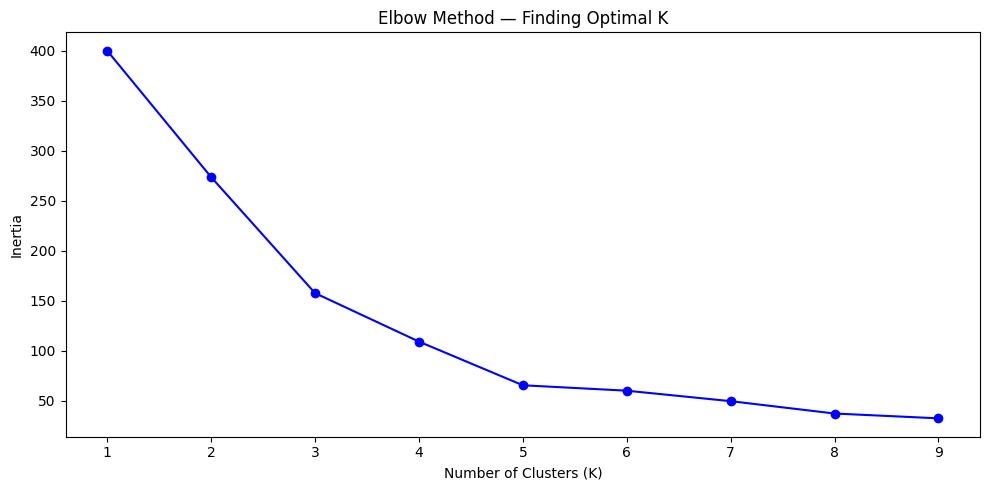

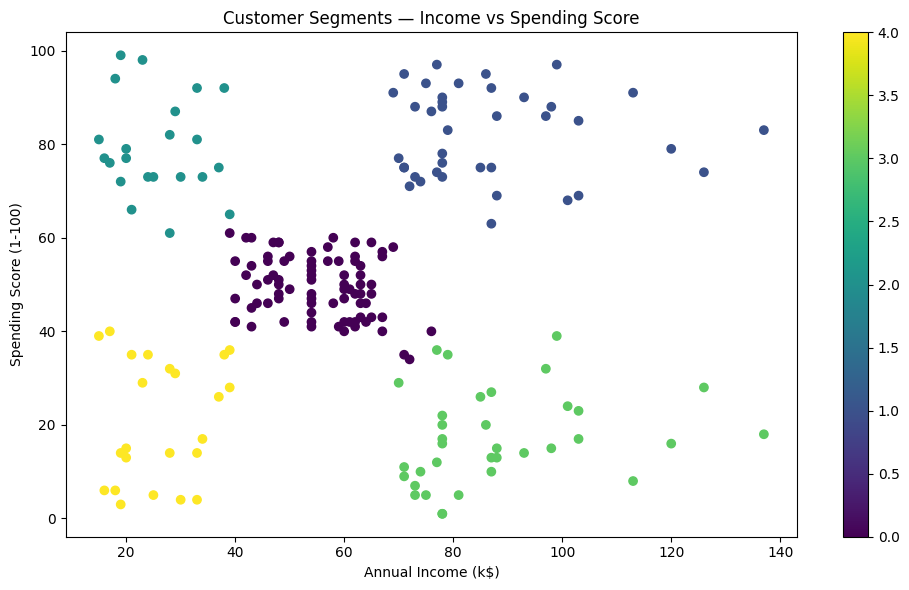


=== Cluster Averages ===
           Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                   
0        42.72               55.30                   49.52
1        32.69               86.54                   82.13
2        25.27               25.73                   79.36
3        41.11               88.20                   17.11
4        45.22               26.30                   20.91

=== Segment Distribution ===
segment
Budget Seniors          81
Premium High Rollers    39
Middle Ground           35
Young Impulsive         23
Careful High Earners    22
Name: count, dtype: int64

=== Business Recommendations ===
Premium High Rollers: VIP treatment, premium products, early access
Young Impulsive: Trendy products, buy now pay later options
Careful High Earners: Value proposition, quality over quantity messaging
Budget Seniors: Loyalty discounts, affordable product lines
Middle Ground: Standard loyalty programs, consistent engagement

==

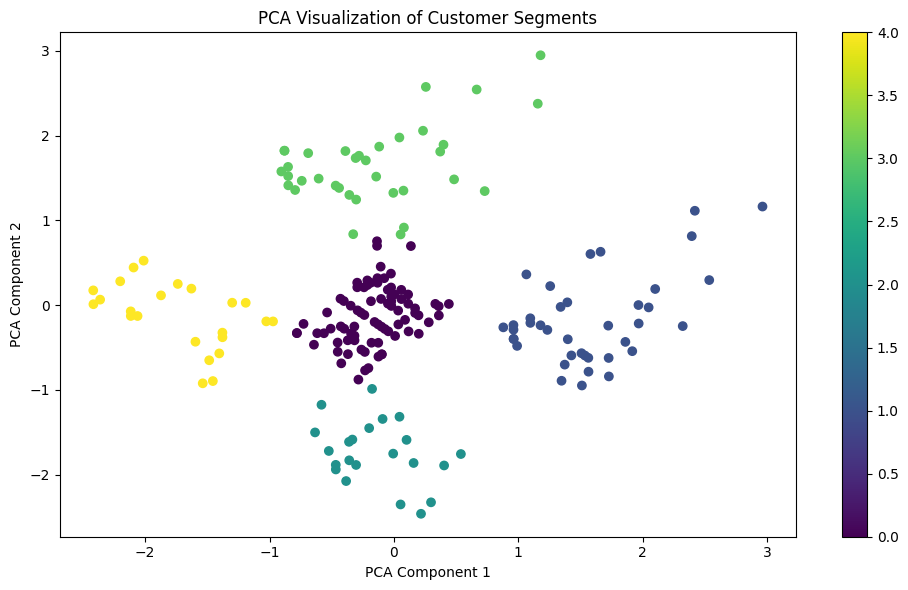

In [2]:
# ============================================================
# CUSTOMER SEGMENTATION USING KMEANS CLUSTERING + PCA
# ============================================================

# ── 1. IMPORTS ──────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── 2. LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv("/content/Mall_Customers.csv")
print(f"Dataset shape: {df.shape}")
print(df.head())

# ── 3. FEATURE SELECTION ─────────────────────────────────────
# Using Income and Spending Score as primary clustering features
# Age added for richer segment profiling
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# ── 4. FEATURE SCALING ───────────────────────────────────────
# KMeans uses distance — scaling mandatory
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 5. ELBOW METHOD — FIND OPTIMAL K ─────────────────────────
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 10), inertia, marker='o', color='blue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K')
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()

# ── 6. TRAIN FINAL KMEANS WITH OPTIMAL K=5 ───────────────────
# K=5 chosen based on elbow curve
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
kmeans.fit(X_scaled)
df['cluster'] = kmeans.labels_

# ── 7. VISUALIZE CLUSTERS ────────────────────────────────────
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['cluster'],
    cmap='viridis'
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments — Income vs Spending Score')
plt.colorbar(scatter)
plt.tight_layout()
plt.savefig('customer_clusters.png', dpi=150)
plt.show()

# ── 8. SEGMENT ANALYSIS ──────────────────────────────────────
# Understand what each cluster represents
print("\n=== Cluster Averages ===")
print(df.groupby('cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2))

# ── 9. NAME THE SEGMENTS ─────────────────────────────────────
cluster_names = {
    0: 'Budget Seniors',
    1: 'Premium High Rollers',
    2: 'Careful High Earners',
    3: 'Middle Ground',
    4: 'Young Impulsive'
}

df['segment'] = df['cluster'].map(cluster_names)

print("\n=== Segment Distribution ===")
print(df['segment'].value_counts())

# ── 10. BUSINESS RECOMMENDATIONS ────────────────────────────
print("\n=== Business Recommendations ===")
recommendations = {
    'Premium High Rollers': 'VIP treatment, premium products, early access',
    'Young Impulsive': 'Trendy products, buy now pay later options',
    'Careful High Earners': 'Value proposition, quality over quantity messaging',
    'Budget Seniors': 'Loyalty discounts, affordable product lines',
    'Middle Ground': 'Standard loyalty programs, consistent engagement'
}

for segment, recommendation in recommendations.items():
    print(f"{segment}: {recommendation}")

# ── 11. PCA VISUALIZATION ────────────────────────────────────
# Reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\n=== PCA Explained Variance ===")
print(f"Component 1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Component 2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.1%}")

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis'
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Visualization of Customer Segments')
plt.colorbar(scatter)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150)
plt.show()